# Week 6 — Ablation Study

**Goals:** Run controlled, one-variable-at-a-time comparisons to measure the contribution
of each pipeline component and architectural choice.

| # | Name | Variable changed | Setting |
|---|---|---|---|
| 1 | `baseline` | — | ROI crop ✔  CLAHE ✔  Augment ✔  ResNet-18 |
| 2 | `no_crop` | Input region | **full image** (no ROI crop) |
| 3 | `no_equalize` | Preprocessing | **no CLAHE** (raw RGB) |
| 4 | `no_augment` | Augmentation | **no augmentation** |
| 5 | `with_stn` | Architecture | **ResNet-18 + STN** |

Everything else is identical across all five runs:
- ResNet-18, pretrained ImageNet weights
- AdamW lr=1e-3, weight-decay=1e-4
- `ReduceLROnPlateau` (factor=0.5, patience=2), early-stop patience=5
- Batch size 128, max 20 epochs, seed 42
- Same mean/std normalisation (computed in Week 2 under the baseline config)


In [5]:
import os, json, time, random, pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import GTSRB
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

try:
    from tqdm import tqdm
except ImportError:
    import subprocess; subprocess.run(["pip", "-q", "install", "tqdm"])
    from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [6]:
PROJECT_ROOT    = pathlib.Path("/content/traffic-sign-classification")
DATA_ROOT       = PROJECT_ROOT / "data"
META_ROOT       = PROJECT_ROOT / "artifacts" / "metadata"
REPORT_ROOT     = PROJECT_ROOT / "reports" / "week6"
CHECKPOINT_ROOT = pathlib.Path("/content/checkpoints_week6")

for p in [DATA_ROOT, META_ROOT, REPORT_ROOT, CHECKPOINT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("REPORT_ROOT   :", REPORT_ROOT)
print("CHECKPOINT_ROOT:", CHECKPOINT_ROOT)


REPORT_ROOT   : /content/traffic-sign-classification/reports/week6
CHECKPOINT_ROOT: /content/checkpoints_week6


In [7]:
# ── Load Week-2 metadata & pipeline config ────────────────────────────────
GTSRB(root=str(DATA_ROOT), split="train", download=True)
GTSRB(root=str(DATA_ROOT), split="test",  download=True)

train_df = pd.read_csv(META_ROOT / "train_metadata_full.csv")

with open(META_ROOT / "week2_pipeline_config.json") as f:
    pipeline_config = json.load(f)

train_meta = train_df[train_df["split"] == "train"].reset_index(drop=True)
val_meta   = train_df[train_df["split"] == "val"  ].reset_index(drop=True)

print(f"Train: {len(train_meta)}  Val: {len(val_meta)}")
print(json.dumps(pipeline_config, indent=2))


Train: 23976  Val: 2664
{
  "seed": 42,
  "image_size": 64,
  "batch_size": 128,
  "use_roi_crop": true,
  "preprocessing": "clahe",
  "pad_ratio": 0.08,
  "mean": [
    0.48077961802482605,
    0.4455212652683258,
    0.45868155360221863
  ],
  "std": [
    0.2539152204990387,
    0.2469169795513153,
    0.25597625970840454
  ]
}


In [8]:
gtsrb_root   = DATA_ROOT / "gtsrb"
test_csv     = gtsrb_root / "GT-final_test.csv"
test_img_dir = gtsrb_root / "GTSRB" / "Final_Test" / "Images"

test_df_raw = pd.read_csv(test_csv, sep=";")

rename_map = {}
for col in test_df_raw.columns:
    c = col.strip().lower()
    if   c == "filename":           rename_map[col] = "filename"
    elif c == "width":              rename_map[col] = "width"
    elif c == "height":             rename_map[col] = "height"
    elif c in ["roi.x1","roi_x1"]:  rename_map[col] = "roi_x1"
    elif c in ["roi.y1","roi_y1"]:  rename_map[col] = "roi_y1"
    elif c in ["roi.x2","roi_x2"]:  rename_map[col] = "roi_x2"
    elif c in ["roi.y2","roi_y2"]:  rename_map[col] = "roi_y2"
    elif c == "classid":            rename_map[col] = "label"

test_df = test_df_raw.rename(columns=rename_map)
test_df["image_path"] = test_df["filename"].apply(
    lambda x: str((test_img_dir / x).resolve()))
test_df["split"] = "test"

missing = [c for c in ["image_path","label","roi_x1","roi_y1","roi_x2","roi_y2"]
           if c not in test_df.columns]
print("Missing columns:", missing)
print(f"Test rows: {len(test_df)}")


Missing columns: []
Test rows: 12630


In [9]:
import sys
sys.path.append(str(PROJECT_ROOT))
from src.datasets import GTSRBCustomDataset

NUM_CLASSES = 43
BATCH_SIZE  = 128

# These stats were computed in Week 2 under the baseline config
# (ROI crop + CLAHE).  We keep them fixed across all ablations so
# that normalisation is *not* the variable under study.
MEAN        = pipeline_config["mean"]
STD         = pipeline_config["std"]
IMG_SIZE    = int(pipeline_config["image_size"])   # 64
PAD_RATIO   = float(pipeline_config["pad_ratio"])  # 0.08

# ── Augmentation transforms ────────────────────────────────────────────────
AUG_TRANSFORMS = [
    transforms.RandomAffine(degrees=10, translate=(0.10, 0.10), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
]

def make_loaders(use_roi_crop: bool,
                 preprocessing: str,   # "clahe" | "equalize" | "none"
                 use_augment: bool):
    """Build train/val/test DataLoaders for one ablation configuration."""

    base = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
    train_tf = transforms.Compose(
        base + (AUG_TRANSFORMS if use_augment else []) +
        [transforms.ToTensor(), transforms.Normalize(MEAN, STD)]
    )
    eval_tf = transforms.Compose(
        base + [transforms.ToTensor(), transforms.Normalize(MEAN, STD)]
    )

    kw = dict(use_roi_crop=use_roi_crop, preprocessing=preprocessing,
              pad_ratio=PAD_RATIO)

    tr_ds  = GTSRBCustomDataset(train_meta, transform=train_tf, **kw)
    val_ds = GTSRBCustomDataset(val_meta,   transform=eval_tf,  **kw)
    te_ds  = GTSRBCustomDataset(test_df,    transform=eval_tf,  **kw)

    ldr_kw = dict(batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
    return (DataLoader(tr_ds,  shuffle=True,  **ldr_kw),
            DataLoader(val_ds, shuffle=False, **ldr_kw),
            DataLoader(te_ds,  shuffle=False, **ldr_kw))

# Quick smoke-test with the baseline config
_tl, _vl, _tel = make_loaders(use_roi_crop=True, preprocessing="clahe", use_augment=True)
x, y = next(iter(_tl))
print(f"Smoke-test batch  x={x.shape}  y={y.shape}")
del _tl, _vl, _tel, x, y


Smoke-test batch  x=torch.Size([128, 3, 64, 64])  y=torch.Size([128])


## Model Definitions

We need two architecture variants:

* **`create_resnet`** — plain ResNet-18, pretrained ImageNet, FC replaced for 43 classes.
* **`ResNetWithSTN`** — the same backbone prepended with the Spatial Transformer Network
  from Week 5 (copied verbatim so this notebook is self-contained).


In [10]:
# ── Plain ResNet-18 ───────────────────────────────────────────────────────
def create_resnet(num_classes: int = 43) -> nn.Module:
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# ── STN module (copied from Week 5 for self-containedness) ────────────────
class SpatialTransformer(nn.Module):
    def __init__(self, in_channels: int = 3, img_size: int = 64,
                 loc_hidden: int = 32):
        super().__init__()
        self.loc_conv = nn.Sequential(
            nn.Conv2d(in_channels, 8, kernel_size=7, padding=3),
            nn.BatchNorm2d(8), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, kernel_size=5, padding=2),
            nn.BatchNorm2d(16), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
        )
        conv_out = (img_size // 4) ** 2 * 16
        self.loc_fc = nn.Sequential(
            nn.Linear(conv_out, loc_hidden), nn.ReLU(inplace=True),
            nn.Linear(loc_hidden, 6),
        )
        nn.init.zeros_(self.loc_fc[-1].weight)
        with torch.no_grad():
            self.loc_fc[-1].bias.copy_(torch.tensor([1., 0., 0., 0., 1., 0.]))

    def forward(self, x):
        feat  = self.loc_conv(x).view(x.size(0), -1)
        theta = self.loc_fc(feat).view(-1, 2, 3)
        grid  = F.affine_grid(theta, x.size(), align_corners=False)
        return F.grid_sample(x, grid, align_corners=False)


class ResNetWithSTN(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 64,
                 loc_hidden: int = 32):
        super().__init__()
        self.stn = SpatialTransformer(in_channels=3, img_size=img_size,
                                      loc_hidden=loc_hidden)
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(self.stn(x))


# ── Sanity-check both architectures ──────────────────────────────────────
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
with torch.no_grad():
    o1 = create_resnet()(dummy)
    o2 = ResNetWithSTN(img_size=IMG_SIZE)(dummy)
print("ResNet output shape   :", o1.shape)
print("ResNet+STN output shape:", o2.shape)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


ResNet output shape   : torch.Size([2, 43])
ResNet+STN output shape: torch.Size([2, 43])


In [11]:
# ── Training / evaluation utilities ──────────────────────────────────────

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    return dict(accuracy=float(acc),
                precision_macro=float(p),
                recall_macro=float(r),
                f1_macro=float(f1))


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, all_preds, all_targets = 0.0, [], []
    for imgs, tgts in tqdm(loader, leave=False):
        imgs, tgts = imgs.to(device, non_blocking=True), tgts.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, tgts)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        all_preds.extend(logits.argmax(1).detach().cpu().tolist())
        all_targets.extend(tgts.cpu().tolist())
    return running_loss / len(loader.dataset), compute_metrics(all_targets, all_preds)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, all_preds, all_targets = 0.0, [], []
    for imgs, tgts in tqdm(loader, leave=False):
        imgs, tgts = imgs.to(device, non_blocking=True), tgts.to(device, non_blocking=True)
        logits = model(imgs)
        running_loss += criterion(logits, tgts).item() * imgs.size(0)
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_targets.extend(tgts.cpu().tolist())
    metrics = compute_metrics(all_targets, all_preds)
    return running_loss / len(loader.dataset), metrics, np.array(all_targets), np.array(all_preds)


def save_checkpoint(path, model, optimizer, epoch, history, best_score):
    torch.save(dict(epoch=epoch,
                    model_state_dict=model.state_dict(),
                    optimizer_state_dict=optimizer.state_dict(),
                    history=history,
                    best_score=best_score), path)

print("Utilities defined.")


Utilities defined.


## Ablation Experiment Matrix

Each row changes **exactly one** variable from the baseline.
All other settings are held at the baseline value.

| Experiment | ROI crop | Preprocessing | Augmentation | Architecture |
|---|---|---|---|---|
| `baseline` | ✔ | CLAHE | ✔ | ResNet-18 |
| `no_crop` | ✗ (full img) | CLAHE | ✔ | ResNet-18 |
| `no_equalize` | ✔ | none | ✔ | ResNet-18 |
| `no_augment` | ✔ | CLAHE | ✗ | ResNet-18 |
| `with_stn` | ✔ | CLAHE | ✔ | ResNet-18 + STN |

> **Note on normalisation:** Mean and std were computed in Week 2 under the baseline config.
> They are held fixed across all runs — if they varied too, we would be changing two variables
> at once.  The small distributional mismatch for `no_crop` / `no_equalize` is negligible
> compared to BatchNorm's online correction inside ResNet.


In [12]:
EXPERIMENTS = [
    # name           roi_crop  preproc   augment  arch
    ("baseline",    True,    "clahe",  True,   "resnet"),
    ("no_crop",     False,   "clahe",  True,   "resnet"),
    ("no_equalize", True,    "none",   True,   "resnet"),
    ("no_augment",  True,    "clahe",  False,  "resnet"),
    ("with_stn",    True,    "clahe",  True,   "resnet_stn"),
]

print(f"Total experiments: {len(EXPERIMENTS)}")
for e in EXPERIMENTS:
    print(f"  {e[0]:15s}  crop={str(e[1]):5s}  preproc={e[2]:7s}  aug={str(e[3]):5s}  arch={e[4]}")


Total experiments: 5
  baseline         crop=True   preproc=clahe    aug=True   arch=resnet
  no_crop          crop=False  preproc=clahe    aug=True   arch=resnet
  no_equalize      crop=True   preproc=none     aug=True   arch=resnet
  no_augment       crop=True   preproc=clahe    aug=False  arch=resnet
  with_stn         crop=True   preproc=clahe    aug=True   arch=resnet_stn


In [13]:
NUM_EPOCHS   = 20
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 5

criterion   = nn.CrossEntropyLoss()
all_results = []

for (exp_name, use_crop, preproc, use_aug, arch) in EXPERIMENTS:
    print("\n" + "=" * 80)
    print(f" {exp_name}  |  crop={use_crop}  preproc={preproc}  aug={use_aug}  arch={arch}")
    print("=" * 80)

    # ── DataLoaders ───────────────────────────────────────────────────────
    train_loader, val_loader, test_loader = make_loaders(
        use_roi_crop=use_crop,
        preprocessing=preproc,
        use_augment=use_aug,
    )

    # ── Model ─────────────────────────────────────────────────────────────
    if arch == "resnet_stn":
        model = ResNetWithSTN(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)
    else:
        model = create_resnet(num_classes=NUM_CLASSES).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2)

    history          = []
    best_val_f1      = -1.0
    patience_counter = 0
    best_ckpt_path   = CHECKPOINT_ROOT / f"{exp_name}_best.pth"
    last_ckpt_path   = CHECKPOINT_ROOT / f"{exp_name}_last.pth"

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        train_loss, train_m = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss,   val_m, yv_true, yv_pred = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step(val_m["f1_macro"])

        lr_now = optimizer.param_groups[0]["lr"]
        row = dict(epoch=epoch, lr=lr_now,
                   train_loss=train_loss,  val_loss=val_loss,
                   train_acc=train_m["accuracy"], train_f1=train_m["f1_macro"],
                   val_acc=val_m["accuracy"],
                   val_precision=val_m["precision_macro"],
                   val_recall=val_m["recall_macro"],
                   val_f1=val_m["f1_macro"],
                   epoch_time=time.time() - t0)
        history.append(row)

        print(f"  E{epoch:02d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "              f"val_acc={val_m['accuracy']:.4f}  val_f1={val_m['f1_macro']:.4f}  lr={lr_now:.2e}")

        save_checkpoint(last_ckpt_path, model, optimizer, epoch, history, best_val_f1)

        if val_m["f1_macro"] > best_val_f1:
            best_val_f1      = val_m["f1_macro"]
            patience_counter = 0
            save_checkpoint(best_ckpt_path, model, optimizer, epoch, history, best_val_f1)
            print(f"    ✔ Best checkpoint saved (epoch {epoch})")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("    ⏹  Early stopping.")
                break

    # ── Save history CSV ─────────────────────────────────────────────────
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(REPORT_ROOT / f"{exp_name}_history.csv", index=False)

    # ── Reload best checkpoint and eval on val + test ─────────────────────
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    _, val_m_best,  yv_true, yv_pred = evaluate(model, val_loader,  criterion, DEVICE)
    _, test_m_best, yt_true, yt_pred = evaluate(model, test_loader, criterion, DEVICE)

    # ── Confusion matrix ─────────────────────────────────────────────────
    cm = confusion_matrix(yv_true, yv_pred, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(f"Val confusion matrix — {exp_name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    fig.colorbar(ax.images[0])
    plt.tight_layout()
    plt.savefig(REPORT_ROOT / f"{exp_name}_confusion_matrix.png", dpi=150)
    plt.close()

    all_results.append(dict(
        experiment=exp_name,
        crop=use_crop, preproc=preproc, augment=use_aug, arch=arch,
        best_epoch=int(ckpt["epoch"]),
        val_acc=round(float(val_m_best["accuracy"]),        4),
        val_prec=round(float(val_m_best["precision_macro"]), 4),
        val_rec=round(float(val_m_best["recall_macro"]),     4),
        val_f1=round(float(val_m_best["f1_macro"]),          4),
        test_acc=round(float(test_m_best["accuracy"]),        4),
        test_prec=round(float(test_m_best["precision_macro"]),4),
        test_rec=round(float(test_m_best["recall_macro"]),    4),
        test_f1=round(float(test_m_best["f1_macro"]),         4),
    ))
    print(f"  ✅  {exp_name}: val_acc={val_m_best['accuracy']:.4f}  test_acc={test_m_best['accuracy']:.4f}")

print("\n\n===== All experiments complete. =====")



 baseline  |  crop=True  preproc=clahe  aug=True  arch=resnet


  E01  train_loss=0.3969  val_loss=0.1016  val_acc=0.9673  val_f1=0.9636  lr=1.00e-03
    ✔ Best checkpoint saved (epoch 1)


  E02  train_loss=0.0941  val_loss=0.0442  val_acc=0.9857  val_f1=0.9828  lr=1.00e-03
    ✔ Best checkpoint saved (epoch 2)


  E03  train_loss=0.0575  val_loss=0.0798  val_acc=0.9790  val_f1=0.9800  lr=1.00e-03


  E04  train_loss=0.0525  val_loss=0.0650  val_acc=0.9861  val_f1=0.9859  lr=1.00e-03
    ✔ Best checkpoint saved (epoch 4)


...

  E17  train_loss=0.0013  val_loss=0.0019  val_acc=0.9992  val_f1=0.9996  lr=1.25e-04


  E18  train_loss=0.0013  val_loss=0.0027  val_acc=0.9996  val_f1=0.9998  lr=1.25e-04
    ✔ Best checkpoint saved (epoch 18)


  E19  train_loss=0.0022  val_loss=0.0021  val_acc=0.9992  val_f1=0.9991  lr=1.25e-04


  E20  train_loss=0.0018  val_loss=0.0009  val_acc=1.0000  val_f1=1.0000  lr=1.25e-04
    ✔ Best checkpoint saved (epoch 20)


  ✅  with_stn: val_acc=1.0000  test_acc=0.9864


===== All experiments complete. =====


In [14]:
# ── Results table ────────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
results_df.to_csv(REPORT_ROOT / "ablation_summary.csv", index=False)

display_cols = ["experiment","best_epoch",
                "val_acc","val_f1",
                "test_acc","test_f1"]
print("\n===== Ablation Results =====\n")
print(results_df[display_cols].to_string(index=False))

# ── Highlight delta vs baseline ──────────────────────────────────────────
baseline_row = results_df[results_df["experiment"] == "baseline"].iloc[0]
print("\n===== Delta vs Baseline (test_f1) =====\n")
for _, row in results_df.iterrows():
    delta = row["test_f1"] - baseline_row["test_f1"]
    sign  = "+" if delta >= 0 else ""
    print(f"  {row['experiment']:15s}  {sign}{delta:+.4f}")



===== Ablation Results =====

 experiment  best_epoch  val_acc  val_f1  test_acc  test_f1
   baseline          15   0.9996  0.9994    0.9861   0.9812
    no_crop          12   1.0000  1.0000    0.9851   0.9778
no_equalize          11   1.0000  1.0000    0.9869   0.9757
 no_augment          10   0.9985  0.9988    0.9836   0.9730
   with_stn          20   1.0000  1.0000    0.9864   0.9799

===== Delta vs Baseline (test_f1) =====

  baseline         ++0.0000
  no_crop          -0.0034
  no_equalize      -0.0055
  no_augment       -0.0082
  with_stn         -0.0013


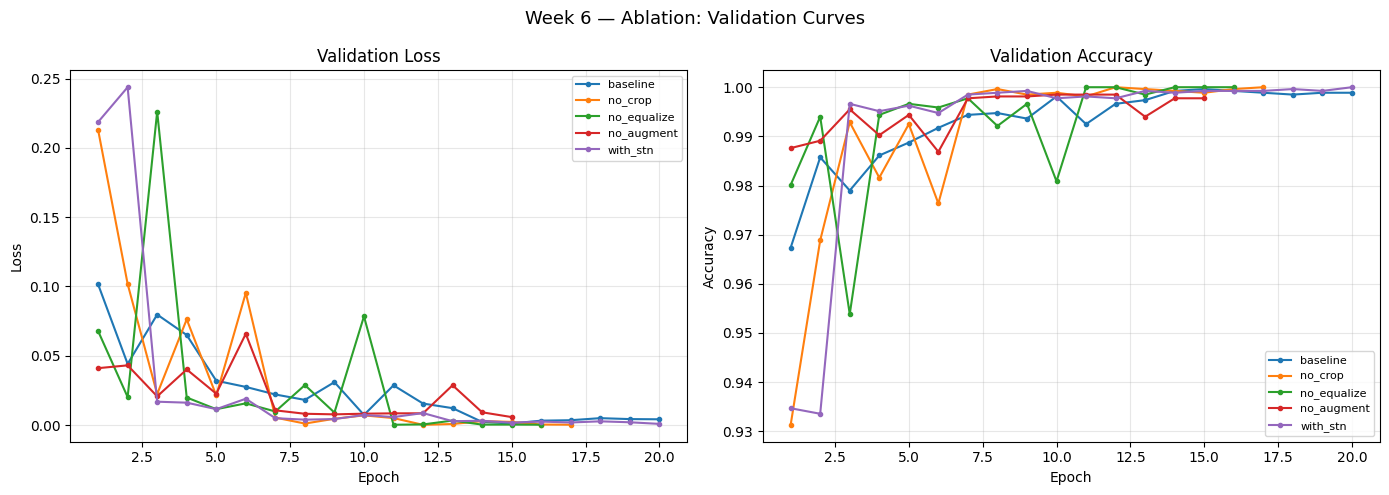

Learning curves saved.


In [15]:
# ── Learning curves for all experiments on one plot ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for exp_name, *_ in EXPERIMENTS:
    hist = pd.read_csv(REPORT_ROOT / f"{exp_name}_history.csv")
    axes[0].plot(hist["epoch"], hist["val_loss"], marker=".", label=exp_name)
    axes[1].plot(hist["epoch"], hist["val_acc"],  marker=".", label=exp_name)

axes[0].set_title("Validation Loss");    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
for ax in axes:
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Week 6 — Ablation: Validation Curves", fontsize=13)
plt.tight_layout()
plt.savefig(REPORT_ROOT / "ablation_val_curves.png", dpi=180)
plt.show()
print("Learning curves saved.")


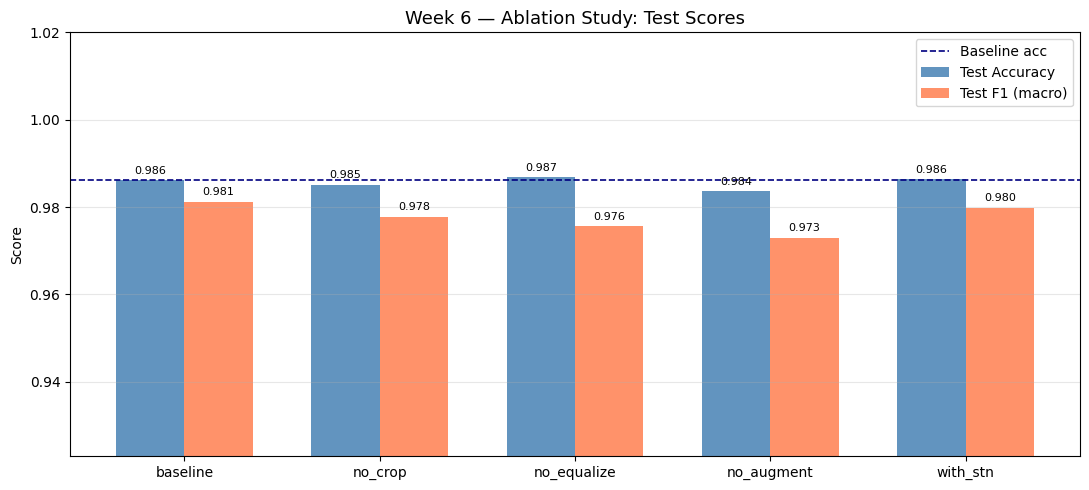

Bar chart saved.


In [16]:
# ── Bar chart: test accuracy + test F1 per experiment ────────────────────
exp_names = results_df["experiment"].tolist()
x = np.arange(len(exp_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, results_df["test_acc"], width, label="Test Accuracy",
               color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width/2, results_df["test_f1"],  width, label="Test F1 (macro)",
               color="coral",     alpha=0.85)

# Annotate bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

# Baseline reference line
baseline_acc = float(results_df.loc[results_df["experiment"]=="baseline", "test_acc"].iloc[0])
ax.axhline(baseline_acc, color="navy", linestyle="--", linewidth=1.2, label="Baseline acc")

ax.set_xticks(x); ax.set_xticklabels(exp_names, fontsize=10)
ax.set_ylim(max(0, results_df[["test_acc","test_f1"]].min().min() - 0.05), 1.02)
ax.set_ylabel("Score"); ax.set_title("Week 6 — Ablation Study: Test Scores", fontsize=13)
ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(REPORT_ROOT / "ablation_bar_chart.png", dpi=200)
plt.show()
print("Bar chart saved.")


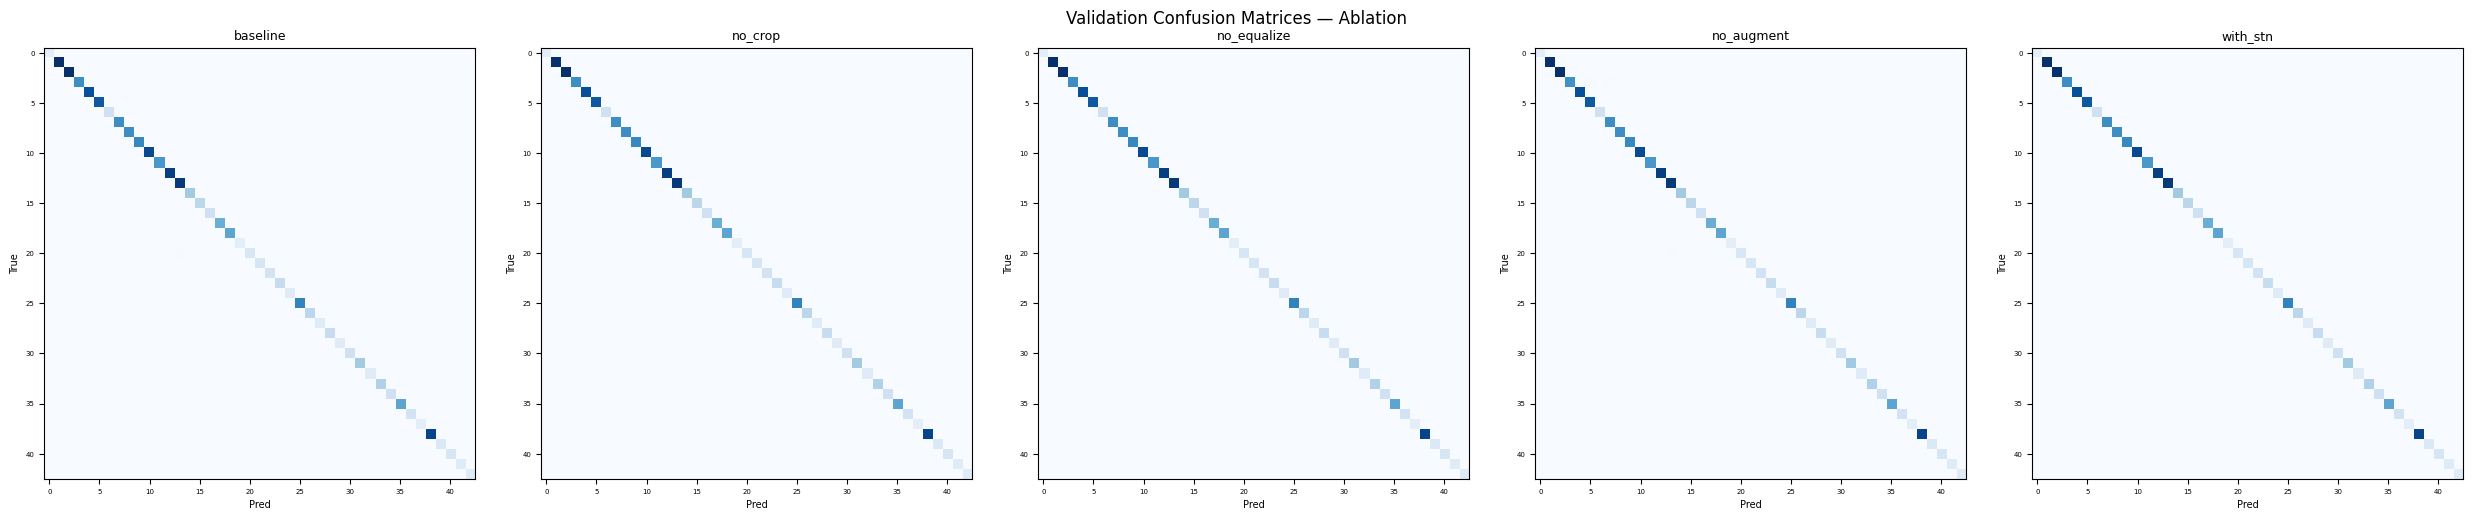

Confusion matrix grid saved.


In [17]:
# ── Display all 5 confusion matrices in a 1×5 grid ──────────────────────
fig, axes = plt.subplots(1, len(EXPERIMENTS), figsize=(len(EXPERIMENTS)*5, 5))

for ax, (exp_name, *_) in zip(axes, EXPERIMENTS):
    ckpt = torch.load(CHECKPOINT_ROOT / f"{exp_name}_best.pth", map_location=DEVICE)
    # Rebuild model + loader for this exp
    ec = {e[0]: e for e in EXPERIMENTS}
    _, use_crop, preproc, use_aug, arch = ec[exp_name]
    _, vl, _ = make_loaders(use_roi_crop=use_crop, preprocessing=preproc, use_augment=use_aug)
    m = (ResNetWithSTN(num_classes=NUM_CLASSES, img_size=IMG_SIZE) if arch == "resnet_stn"
         else create_resnet(num_classes=NUM_CLASSES)).to(DEVICE)
    m.load_state_dict(ckpt["model_state_dict"])
    _, _, yv, yp = evaluate(m, vl, nn.CrossEntropyLoss(), DEVICE)
    cm = confusion_matrix(yv, yp, labels=list(range(NUM_CLASSES)))
    ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(exp_name, fontsize=9)
    ax.set_xlabel("Pred", fontsize=7); ax.set_ylabel("True", fontsize=7)
    ax.tick_params(labelsize=5)

plt.suptitle("Validation Confusion Matrices — Ablation", fontsize=12)
plt.tight_layout()
plt.savefig(REPORT_ROOT / "ablation_confusion_matrices.png", dpi=150)
plt.show()
print("Confusion matrix grid saved.")


## How to Interpret Results

Read the **delta vs baseline** table produced in Cell 10 alongside the bar chart:

| Delta direction | Interpretation |
|---|---|
| `no_crop` ↓ | ROI cropping is **helping** — removing the background makes a meaningful difference |
| `no_crop` ≈ | The model generalises across the full image; crop is less critical |
| `no_equalize` ↓ | CLAHE contrast enhancement **contributes** to accuracy |
| `no_equalize` ≈ | ResNet's BatchNorm is compensating for contrast variation on its own |
| `no_augment` ↓ | Augmentation provides **regularisation** benefit |
| `no_augment` ↑ | Augmentation was adding noise (unlikely for GTSRB but possible) |
| `with_stn` ↑ | STN spatial attention **improves** over the plain backbone |
| `with_stn` ↓ | STN overhead hurts on this dataset (small images, already well-cropped) |

These findings will feed directly into the **Week 7 error analysis**:
focus GradCAM and saliency visualisations on the conditions that show the largest performance gap.

## Next Steps → Week 7 (Interpretation & Error Analysis)

1. Load the **best checkpoint** from the ablation study.
2. Build a confusion matrix with per-class breakdown.
3. Collect the most common failure cases (most-confused class pairs).
4. Implement **Grad-CAM** to visualise where the model attends on correct vs incorrect predictions.
5. Produce saliency maps for hard examples.
